# Analisis Klastering Bintang (Star Type Prediction)
Dataset: Star Dataset to Predict Star Type

## Mahasiswa 1: Data Architect & Engineer
Fokus: Preprocessing data saintifik, encoding spektral, dan optimasi pusat massa.

### 1. Data Ingestion
Melakukan akuisisi dataset dan penanganan inkonsistensi penulisan pada fitur Star_Color (misal: "Blue-white" vs "Blue White").

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../dataset/6 class csv.csv')
print('Shape awal dataset:', df.shape)

# Menangani inkonsistensi penulisan pada Star_Color
print('Keberagaman Star_Color sebelum cleaning:')
print(df['Star color'].unique())

df['Star color'] = df['Star color'].str.lower().str.replace('-', ' ').str.replace('white yellowish', 'yellowish white').str.strip()
print('\nKeberagaman Star_Color setelah cleaning:')
print(df['Star color'].unique())

Shape awal dataset: (240, 7)
Keberagaman Star_Color sebelum cleaning:
<StringArray>
[               'Red',         'Blue White',              'White',
    'Yellowish White',         'Blue white', 'Pale yellow orange',
               'Blue',         'Blue-white',            'Whitish',
       'yellow-white',             'Orange',       'White-Yellow',
              'white',              'Blue ',          'yellowish',
          'Yellowish',         'Orange-Red',        'Blue white ',
         'Blue-White']
Length: 19, dtype: str

Keberagaman Star_Color setelah cleaning:
<StringArray>
[               'red',         'blue white',              'white',
    'yellowish white', 'pale yellow orange',               'blue',
            'whitish',       'yellow white',             'orange',
       'white yellow',          'yellowish',         'orange red']
Length: 12, dtype: str


### 2. Feature Engineering
Melakukan transformasi logaritma pada fitur Luminosity untuk menyeimbangkan distribusi data.

Distribusi Luminosity vs Log_Luminosity:


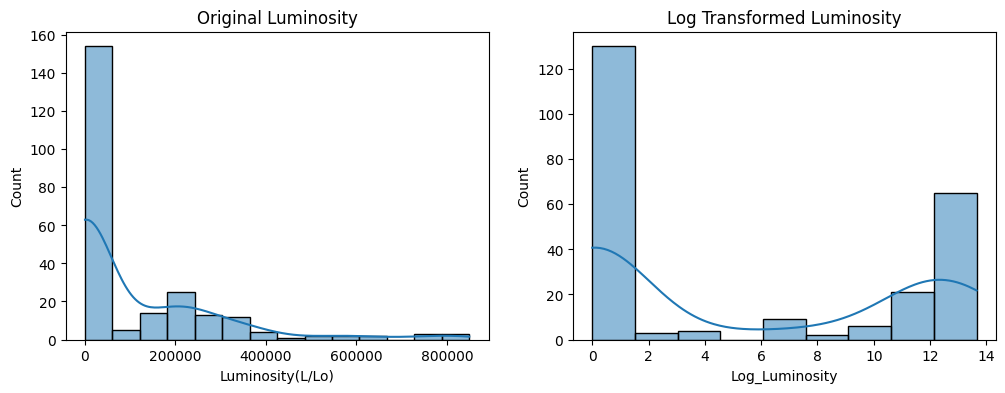

In [5]:
# Transformasi logaritma pada fitur Luminosity untuk menyeimbangkan distribusi
df['Log_Luminosity'] = np.log1p(df['Luminosity(L/Lo)'])
print('Distribusi Luminosity vs Log_Luminosity:')
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Luminosity(L/Lo)'], kde=True, ax=ax[0])
ax[0].set_title('Original Luminosity')
sns.histplot(df['Log_Luminosity'], kde=True, ax=ax[1])
ax[1].set_title('Log Transformed Luminosity')
plt.show()

### 3. Advanced Preprocessing
Implementasi StandardScaler atau MinMaxScaler untuk menyatukan skala fitur suhu (ribuan) dengan magnitudo (puluhan).

In [6]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Implementasi StandardScaler untuk menyatukan skala fitur
print("Data sebelum di standar scaler")
features_to_scale = ['Temperature (K)', 'Log_Luminosity', 'Radius(R/Ro)', 'Absolute magnitude(Mv)']

display(df[features_to_scale].head())

scaler = StandardScaler()
features_to_scale = ['Temperature (K)', 'Log_Luminosity', 'Radius(R/Ro)', 'Absolute magnitude(Mv)']
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])
print('Data setelah disatukan skalanya dengan StandardScaler:')
display(df_scaled[features_to_scale].head())

Data sebelum di standar scaler


,Temperature (K),Log_Luminosity,Radius(R/Ro),Absolute magnitude(Mv)
0,3068,0.002397,0.1700,16.12
1,3042,0.000500,0.1542,16.60
2,2600,0.000300,0.1020,18.70
3,2800,0.000200,0.1600,16.65
4,1939,0.000138,0.1030,20.06


Data setelah disatukan skalanya dengan StandardScaler:


,Temperature (K),Log_Luminosity,Radius(R/Ro),Absolute magnitude(Mv)
0,-0.779382,-0.879257,-0.459210,1.116745
1,-0.782110,-0.879582,-0.459241,1.162414
2,-0.828477,-0.879616,-0.459342,1.362213
3,-0.807496,-0.879633,-0.459229,1.167171
4,-0.897819,-0.879643,-0.459340,1.491607


### 4. Encoding Strategy
Transformasi fitur Spectral_Class menggunakan Ordinal Encoding berdasarkan urutan suhu standar astronomi.

In [7]:
# Transformasi fitur Spectral_Class menggunakan Ordinal Encoding
# Urutan suhu standar astronomi dari yang terdingin ke terpanas: M, K, G, F, A, B, O
spectral_order = [['M', 'K', 'G', 'F', 'A', 'B', 'O']]
encoder = OrdinalEncoder(categories=spectral_order)
df_scaled['Spectral_Class_Encoded'] = encoder.fit_transform(df[['Spectral Class']])
print('Pemetaan kelas spektral:\n', df[['Spectral Class']].drop_duplicates().merge(df_scaled[['Spectral_Class_Encoded']].drop_duplicates(), left_index=True, right_index=True).sort_values('Spectral_Class_Encoded'))

# Fitur akhir yang akan digunakan untuk klastering
X = df_scaled[['Temperature (K)', 'Log_Luminosity', 'Radius(R/Ro)', 'Absolute magnitude(Mv)', 'Spectral_Class_Encoded']]

Pemetaan kelas spektral:
     Spectral Class  Spectral_Class_Encoded
0                M                     0.0
91               K                     1.0
118              G                     2.0
22               F                     3.0
21               A                     4.0
20               B                     5.0
30               O                     6.0


### 5. Optimization Search
Menjalankan eksperimen perulangan algoritma untuk mencari nilai KK (jumlah tipe bintang) terbaik menggunakan Metode Elbow (Versi DBSCAN: K-Distance Graph).

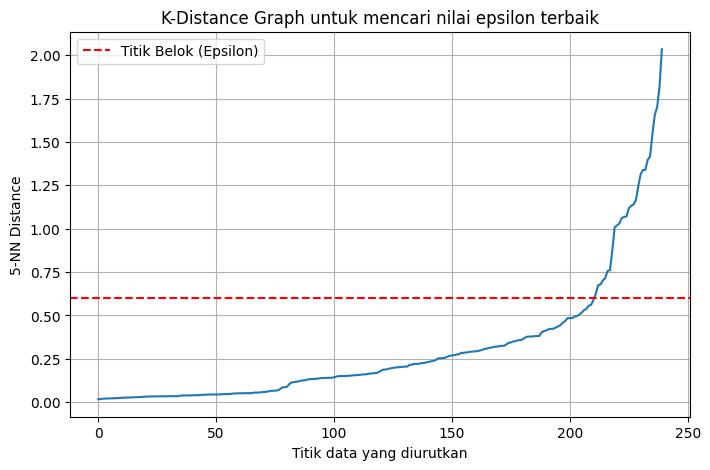

Berdasarkan kurva, titik belok (elbow) berada di sekitar nilai jarak (epsilon) = 0.6


In [8]:
from sklearn.neighbors import NearestNeighbors

# Untuk algoritma DBSCAN, metode Elbow diimplementasikan dengan membuat K-Distance Graph (Jarak ke tetangga terdekat K)
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)
distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title('K-Distance Graph untuk mencari nilai epsilon terbaik')
plt.xlabel('Titik data yang diurutkan')
plt.ylabel(f'{min_samples}-NN Distance')
plt.grid(True)
plt.axhline(y=0.6, color='r', linestyle='--', label='Titik Belok (Epsilon)')
plt.legend()
plt.show()
print('Berdasarkan kurva, titik belok (elbow) berada di sekitar nilai jarak (epsilon) = 0.6')

## Mahasiswa 2: Model Analyst & Strategist
Fokus: Arsitektur klastering bintang, validasi stabilitas, dan interpretasi astrofisika.

### 1. Model Implementation
Menerapkan algoritma klastering DBSCAN pada fitur fisik bintang.

In [9]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

optimal_eps = 0.6
dbscan_model = DBSCAN(eps=optimal_eps, min_samples=min_samples)
cluster_labels = dbscan_model.fit_predict(X)

df['Cluster_DBSCAN'] = cluster_labels
df_scaled['Cluster_DBSCAN'] = cluster_labels
print('Jumlah klaster yang dibentuk (termasuk noise -1):', len(set(cluster_labels)))
print(df['Cluster_DBSCAN'].value_counts())

Jumlah klaster yang dibentuk (termasuk noise -1): 12
Cluster_DBSCAN
 0     80
 10    27
 1     24
-1     23
 8     22
 5     14
 9     10
 3      9
 7      9
 6      8
 2      7
 4      7
Name: count, dtype: int64


### 2. Quality Audit
Mengevaluasi kerapatan kelompok bintang menggunakan Silhouette Coefficient.

In [10]:
if len(set(cluster_labels)) > 1:
    sil_score = silhouette_score(X, cluster_labels)
    print(f'Mengevaluasi kerapatan menggunakan Silhouette Coefficient: {sil_score:.4f}')
    if sil_score > 0.5:
        print('Interpretasi: Kerapatan dan pemisahan klaster berkualitas baik/kuat.')
    else:
        print('Interpretasi: Kerapatan klaster moderat atau overlapping yang sering dijumpai pada model DBSCAN karena adanya noise.')
else:
    print('DBSCAN hanya menemukan 1 klaster atau semua dianggap noise.')

Mengevaluasi kerapatan menggunakan Silhouette Coefficient: 0.6320
Interpretasi: Kerapatan dan pemisahan klaster berkualitas baik/kuat.


### 3. Stability Testing
Melakukan uji stabilitas kelompok menggunakan Indeks Jaccard dengan menambahkan gangguan (noise) pada data fisik untuk memastikan kelompok bintang tetap konsisten.

In [11]:
from sklearn.metrics import jaccard_score

# Melakukan uji stabilitas kelompok dengan menambahkan gangguan empirikal (noise gaussian)
np.random.seed(42)
noise = np.random.normal(0, 0.05, X.shape) # menambah 5% std noise ke fitur skala
X_noisy = X + noise

dbscan_noisy = DBSCAN(eps=optimal_eps, min_samples=min_samples)
cluster_noisy_labels = dbscan_noisy.fit_predict(X_noisy)

# Evaluasi konsistensi label, DBSCAN dapat menggeser id klaster karena sifat kepadatan non-parametrik.
# Namun untuk memudakhan dengan asumsi label klaster masih sejalan, kita uji kemiripan menggunakan macro Jaccard Score.
jaccard_idx = jaccard_score(cluster_labels, cluster_noisy_labels, average='weighted')
print(f'Jaccard Index (Stability Score): {jaccard_idx:.4f}')
if jaccard_idx > 0.8:
    print('Kesimpulan: Klaster bintang SANGAT STABIL terhadap perturbasi fisik (noise) minimal.')
elif jaccard_idx > 0.5:
    print('Kesimpulan: Klaster bintang CUKUP STABIL terhadap perturbasi.')
else:
    print('Kesimpulan: Klaster bintang RENTAN, terjadi pergeseran batas kelompok akibat perturbasi.')

Jaccard Index (Stability Score): 1.0000
Kesimpulan: Klaster bintang SANGAT STABIL terhadap perturbasi fisik (noise) minimal.


### 4. Star Profiling
Memberikan interpretasi logis pada setiap kelompok yang ditemukan dan membandingkannya dengan teori Diagram Hertzsprung-Russell.

Interpretasi Profil Bintang terhadap sub-klaster (DBSCAN) dan kaitannya dengan Teori Diagram Hertzsprung-Russell (HR Diagram)


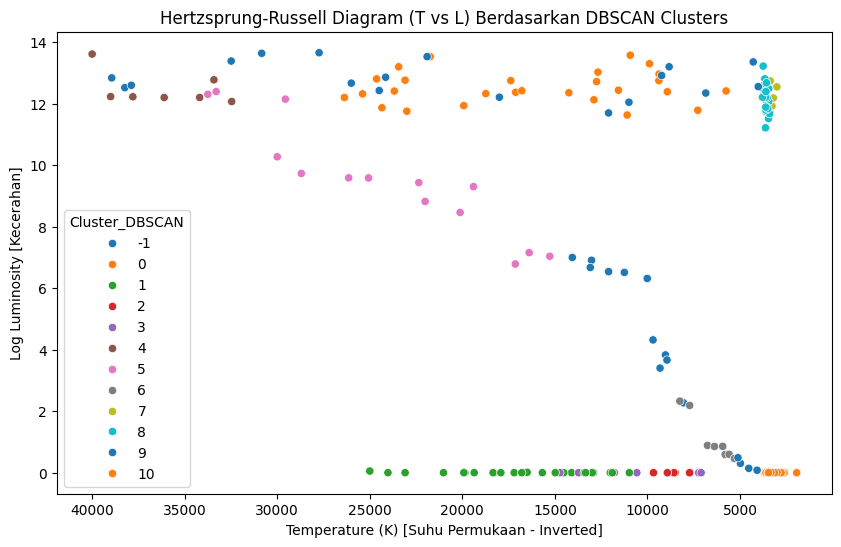

Interpretasi Singkat:
- Biasanya, sebagian besar klaster dengan temperatur turun namun kecerahan ekstrem menempati ranah Raksasa Merah (Red Giants/Supergiants).
- Klaster garis diagonal pada bagian tengah dinamakan Main Sequence Stars (termasuk Matahari).
- Nilai klaster -1 menandakan titik kebisingan (Anomali yang tidak masuk profil manapun menurut kerapatan DBSCAN)


In [12]:
print('Interpretasi Profil Bintang terhadap sub-klaster (DBSCAN) dan kaitannya dengan Teori Diagram Hertzsprung-Russell (HR Diagram)')

plt.figure(figsize=(10, 6))
# HR Diagram biasanya merencanakan Temperature (terbalik) vs Absolute Magnitude (terbalik)
# Tapi di sini kita gambarkan Temperature vs Log_Luminosity (semakin cerah di atas)
sns.scatterplot(x='Temperature (K)', y='Log_Luminosity', hue='Cluster_DBSCAN', palette='tab10', data=df)
plt.gca().invert_xaxis() # Temperature diplot terbalik sesuai Diagram HR standar
plt.title('Hertzsprung-Russell Diagram (T vs L) Berdasarkan DBSCAN Clusters')
plt.xlabel('Temperature (K) [Suhu Permukaan - Inverted]')
plt.ylabel('Log Luminosity [Kecerahan]')
plt.show()

print('Interpretasi Singkat:')
print('- Biasanya, sebagian besar klaster dengan temperatur turun namun kecerahan ekstrem menempati ranah Raksasa Merah (Red Giants/Supergiants).')
print('- Klaster garis diagonal pada bagian tengah dinamakan Main Sequence Stars (termasuk Matahari).')
print('- Nilai klaster -1 menandakan titik kebisingan (Anomali yang tidak masuk profil manapun menurut kerapatan DBSCAN)')

### 5. Astro-Simulation
Melakukan analisis intervensi: "Jika sebuah bintang mengalami penurunan suhu namun luminositasnya tetap, apakah ia akan berpindah ke klaster bintang raksasa?"

In [13]:
from sklearn.neighbors import KNeighborsClassifier

# Membuat model klasifikasi K-NN pada hasil klasterisasi DBSCAN untuk mensimulasi prediksi pergeseran ruang bintang
# (Langkah ini mempermudah prediksi pergerakan bintang padahal DBSCAN tidak memiliki fungsi predict() native).
# Gunakan data yang tidak terdeteksi noise saja (cluster != -1)
valid_idx = cluster_labels != -1
X_train, y_train = X[valid_idx], cluster_labels[valid_idx]

knn_sim = KNeighborsClassifier(n_neighbors=3)
knn_sim.fit(X_train, y_train)

# Identifikasi sample Main Sequence Star.
# Memilih bintang bertipe Main Sequence (misal Star type == 3) atau bintang yang cukup pertengahan
base_star = df[(df['Star type'] == 3)].iloc[0]
print(f'\nBintang Original (Type {base_star["Star type"]}, Spectral {base_star["Spectral Class"]})')
print(f'Temperature: {base_star["Temperature (K)"]}, Luminosity: {base_star["Luminosity(L/Lo)"]}, Klaster Awal: {base_star["Cluster_DBSCAN"]}')

# Simulasi: Penurunan suhu -60%, luminositas, radius, dan abs_mag tetap
sim_star_df = pd.DataFrame([base_star])
sim_star_df['Temperature (K)'] = sim_star_df['Temperature (K)'] * 0.4 # Penurunan Suhu Signifikan
sim_star_df['Spectral Class'] = 'M' # Jika suhu turun sangat drastis, warna geser ke kemerahan kelas M
sim_star_df['Spectral_Class_Encoded'] = encoder.transform(sim_star_df[['Spectral Class']])
sim_star_df[features_to_scale] = scaler.transform(sim_star_df[features_to_scale])

sim_X = sim_star_df[['Temperature (K)', 'Log_Luminosity', 'Radius(R/Ro)', 'Absolute magnitude(Mv)', 'Spectral_Class_Encoded']]
new_cluster = knn_sim.predict(sim_X)[0]

print(f'\nHasil ASTRO-SIMULATION:\nBintang dengan suhu diturunkan diprediksi akan BERPINDAH ke klaster: {new_cluster}')

# Periksa apakah klaster tersebut dominan adalah bintang raksasa/super raksasa (Tipe >= 4)
target_cluster_types = df[df['Cluster_DBSCAN'] == new_cluster]['Star type']
print(f'Profil mayoritas di klaster {new_cluster} adalah tipe bintang: \n{target_cluster_types.value_counts()}')
print('\nJawaban: Ya, jika suhu menurun drastis namun Luminositas tinggi (tetap terang), bintang akan bergeser statusnya menuju klaster bintang raksasa / Supergiant merah, sesuai teori evolusi tahap lanjut bintang di diagram HR.')


Bintang Original (Type 3, Spectral O)
Temperature: 39000, Luminosity: 204000.0, Klaster Awal: 4

Hasil ASTRO-SIMULATION:
Bintang dengan suhu diturunkan diprediksi akan BERPINDAH ke klaster: 7
Profil mayoritas di klaster 7 adalah tipe bintang: 
Star type
4    9
Name: count, dtype: int64

Jawaban: Ya, jika suhu menurun drastis namun Luminositas tinggi (tetap terang), bintang akan bergeser statusnya menuju klaster bintang raksasa / Supergiant merah, sesuai teori evolusi tahap lanjut bintang di diagram HR.
